## 1. Analysis

In [115]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')

In [116]:
try:
    df = pd.read_csv('german_credit_data.csv')
except FileNotFoundError:
    df = pd.DataFrame()
    print('No file \'german_credit_data.csv\' found in directory')

df.columns = [(c.replace(' ', '_')).lower() for c in df.columns]
df_og = df.copy()

df.head()

,unnamed:_0,age,sex,job,housing,saving_accounts,checking_account,credit_amount,duration,purpose,risk
0,0,67,male,2,own,NaN,little,1169,6,radio/TV,good
1,1,22,female,2,own,little,moderate,5951,48,radio/TV,bad
2,2,49,male,1,own,little,NaN,2096,12,education,good
3,3,45,male,2,free,little,little,7882,42,furniture/equipment,good
4,4,53,male,2,free,little,little,4870,24,car,bad


Notes:
- Job is 0 - 3, ranking job importance from least to most
- 'good'/'bad' in 'risk' column corresponds to low/high risk
- German dataset, so 'credit_amount' column is per euro

<br>

In [117]:
df['risk'].value_counts()
# biased towards low credit risk, could rebalance samples if needed

risk
good    700
bad     300
Name: count, dtype: int64

In [118]:
df.info()
# savings and checking accounts will probably be significant predictors, may need to drop rows that are missing this data

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   unnamed:_0        1000 non-null   int64
 1   age               1000 non-null   int64
 2   sex               1000 non-null   str  
 3   job               1000 non-null   int64
 4   housing           1000 non-null   str  
 5   saving_accounts   817 non-null    str  
 6   checking_account  606 non-null    str  
 7   credit_amount     1000 non-null   int64
 8   duration          1000 non-null   int64
 9   purpose           1000 non-null   str  
 10  risk              1000 non-null   str  
dtypes: int64(5), str(6)
memory usage: 115.1 KB


In [119]:
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
unnamed:_0,1000.0,NaN,NaN,NaN,499.5,288.819436,0.0,249.75,499.5,749.25,999.0
age,1000.0,NaN,NaN,NaN,35.546,11.375469,19.0,27.0,33.0,42.0,75.0
sex,1000,2,male,690,NaN,NaN,NaN,NaN,NaN,NaN,NaN
job,1000.0,NaN,NaN,NaN,1.904,0.653614,0.0,2.0,2.0,2.0,3.0
housing,1000,3,own,713,NaN,NaN,NaN,NaN,NaN,NaN,NaN
saving_accounts,817,4,little,603,NaN,NaN,NaN,NaN,NaN,NaN,NaN
checking_account,606,3,little,274,NaN,NaN,NaN,NaN,NaN,NaN,NaN
credit_amount,1000.0,NaN,NaN,NaN,3271.258,2822.736876,250.0,1365.5,2319.5,3972.25,18424.0
duration,1000.0,NaN,NaN,NaN,20.903,12.058814,4.0,12.0,18.0,24.0,72.0
purpose,1000,8,car,337,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [120]:
df.isna().sum()

unnamed:_0            0
age                   0
sex                   0
job                   0
housing               0
saving_accounts     183
checking_account    394
credit_amount         0
duration              0
purpose               0
risk                  0
dtype: int64

In [121]:
df.duplicated().sum()

np.int64(0)

In [122]:
print(df.shape)
df = df.dropna().reset_index(drop=True)
df.shape

(1000, 11)


(522, 11)

In [123]:
if 'unnamed:_0' in df.columns:
    df.drop(columns='unnamed:_0', inplace=True)

df.columns

Index(['age', 'sex', 'job', 'housing', 'saving_accounts', 'checking_account',
       'credit_amount', 'duration', 'purpose', 'risk'],
      dtype='str')

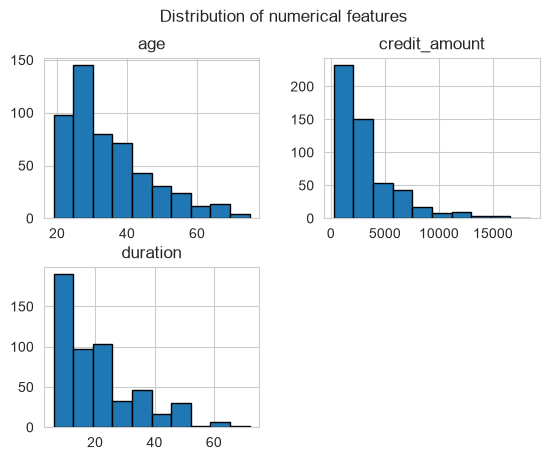

In [124]:
df[['age', 'credit_amount', 'duration']].hist(bins=10, edgecolor = 'black')
plt.suptitle('Distribution of numerical features')
plt.show()

# all right skewed, mode < median < mean

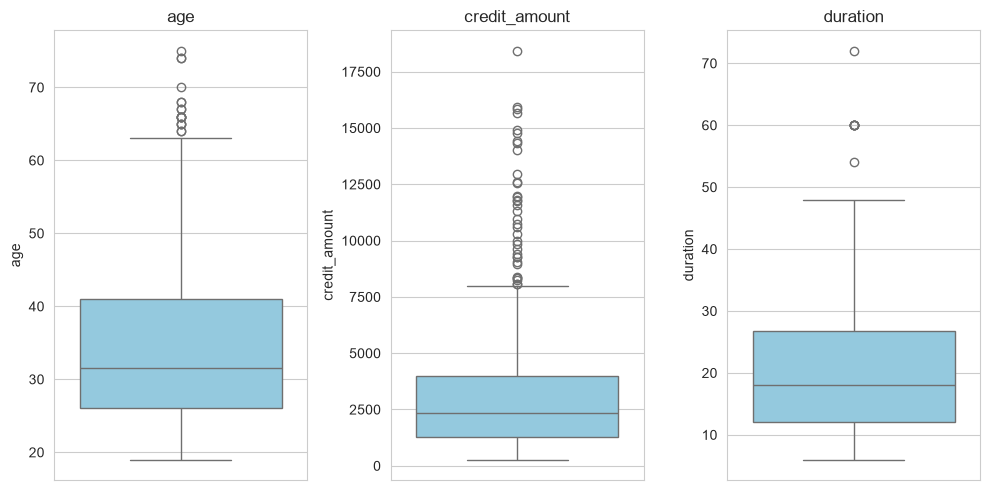

In [125]:
plt.figure(figsize=(10,5))
for i, col in enumerate(['age', 'credit_amount', 'duration']):
    plt.subplot(1, 3, i+1)
    sns.boxplot(y=df[col], color='skyblue')
    plt.title(col)

plt.tight_layout()
plt.show()


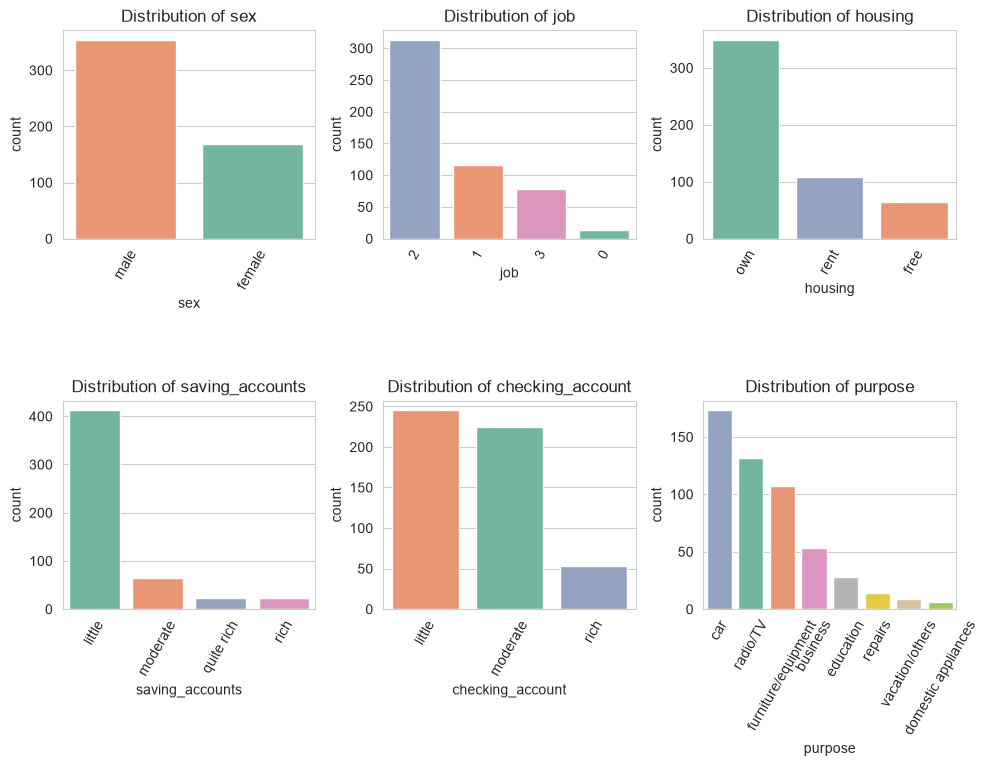

In [126]:
categorical_cols = ['sex', 'job', 'housing', 'saving_accounts', 'checking_account', 'purpose']

plt.figure(figsize=(10, 10))
for i, col in enumerate(categorical_cols):
    plt.subplot(3, 3, i+1)
    sns.countplot(data=df, x=col, palette='Set2', hue=col, legend=False, order=df[col].value_counts().index)
    plt.title(f'Distribution of {col}')
    plt.xticks(rotation=60)

plt.tight_layout()
plt.show()


In [127]:
# default correlation measure: pearson
corr = df[['age', 'job', 'credit_amount', 'duration']].corr()
corr

,age,job,credit_amount,duration
age,1.000000,0.039771,0.082014,0.001549
job,0.039771,1.000000,0.334721,0.200794
credit_amount,0.082014,0.334721,1.000000,0.613298
duration,0.001549,0.200794,0.613298,1.000000


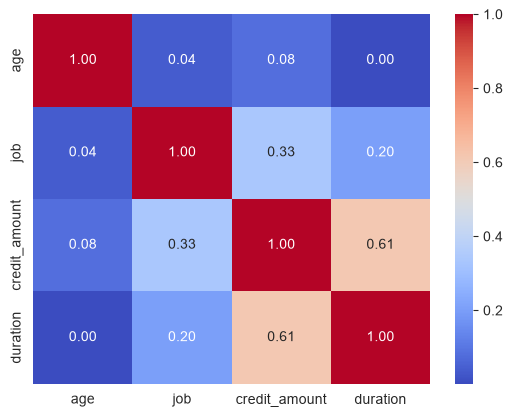

In [128]:
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.show()

# low correlation across these variables (values close to 0), except credit amount and duration (positive correlation)

In [129]:
# pivot table - get one variable in terms of another variable (default operation is mean) for each value of a third variable
# in this case, housing in terms of mean credit amount for each housing value, for each purpose

pd.pivot_table(df, values='credit_amount', index='housing',columns='purpose')

purpose,business,car,domestic appliances,education,furniture/equipment,radio/TV,repairs,vacation/others
housing,,,,,,,,
free,4705.000000,5180.314286,NaN,5314.250000,4419.444444,2097.000000,1190.0,7842.666667
own,3725.973684,3120.485437,1333.5,2625.076923,3031.100000,2307.613861,2993.5,10321.833333
rent,6180.833333,3398.285714,NaN,2627.857143,2890.285714,2138.000000,2384.0,NaN


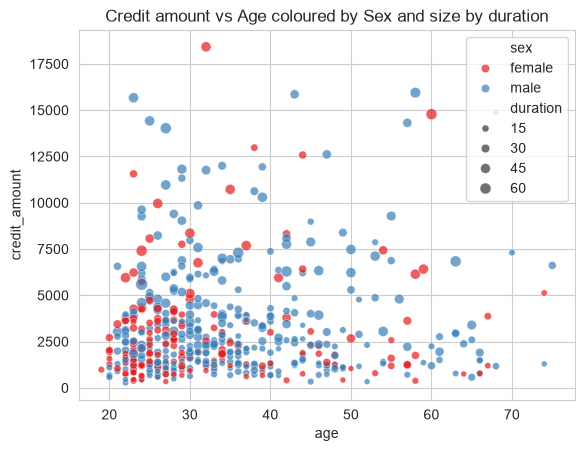

In [130]:
sns.scatterplot(data=df, x='age', y='credit_amount', hue='sex', size='duration', alpha=0.7, palette='Set1')
plt.title('Credit amount vs Age coloured by Sex and size by duration')

plt.show()

# most data grouped in low credit amount and low age and tend not to have low duration
# highest duration also correlates with higher credit amount and age

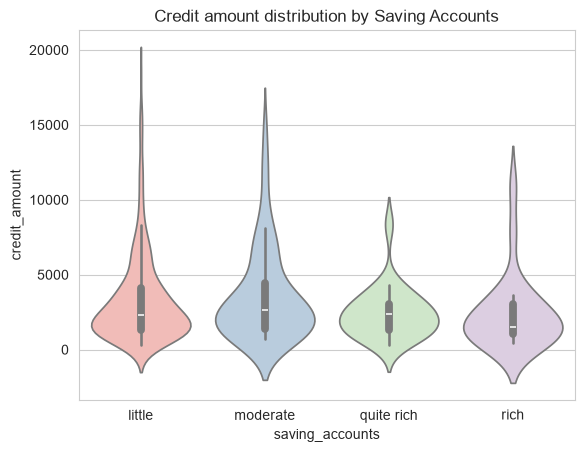

In [131]:
sns.violinplot(data=df, x='saving_accounts', y='credit_amount', palette='Pastel1', hue='saving_accounts', legend=False)
plt.title('Credit amount distribution by Saving Accounts')

plt.show()

# large differences in outliers between distrubtion of credit amount for each category of saving account
# quartiles mostly similar

In [132]:
df['risk'].value_counts(normalize=True) * 100
# dataset target has evened out and lowered effect of potential dataset bias, at the cost of some data loss (dropped rows)

risk
good    55.747126
bad     44.252874
Name: proportion, dtype: float64

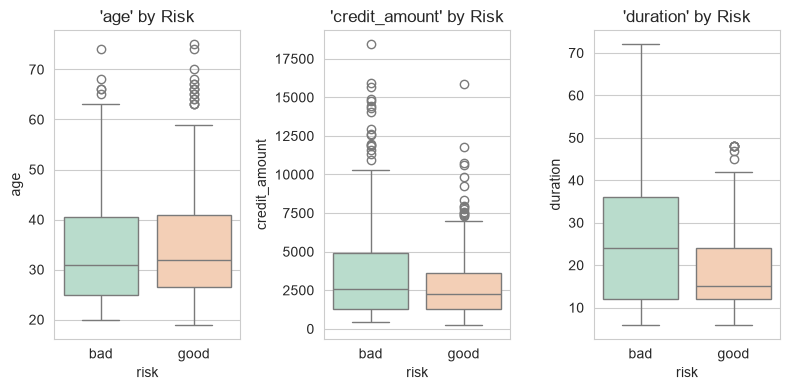

In [133]:
plt.figure(figsize=(8, 4))

for i, col in enumerate(['age', 'credit_amount', 'duration']):
    plt.subplot(1, 3, i+1)
    sns.boxplot(data=df, x='risk', y=col, palette='Pastel2', hue='risk', legend=False)
    plt.title(f'\'{col}\' by Risk')

plt.tight_layout()
plt.show()

# age, credit amount, and duration distribution by risk

In [134]:
df.groupby('risk')[['age', 'credit_amount', 'duration']].mean()

,age,credit_amount,duration
risk,,,
bad,34.147186,3881.090909,25.445887
good,35.477663,2800.594502,18.079038


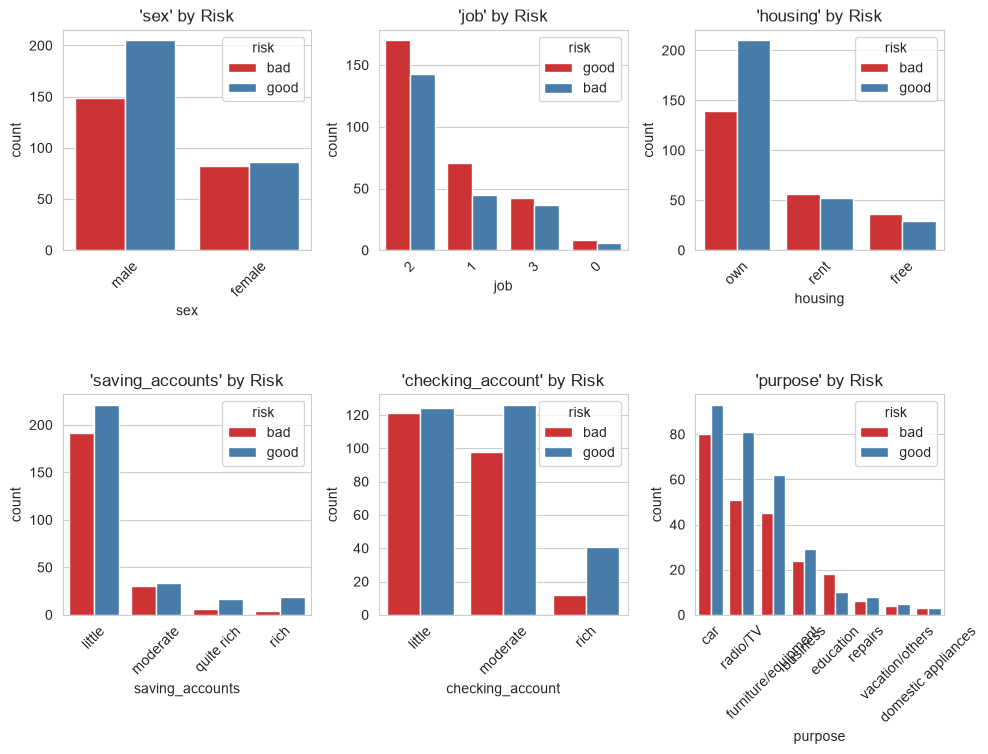

In [135]:
plt.figure(figsize=(10, 10))

for i, col in enumerate(categorical_cols):
    plt.subplot(3, 3, i+1)
    sns.countplot(data=df, x=col, palette='Set1', hue='risk', order=df[col].value_counts().index)
    plt.title(f'\'{col}\' by Risk')
    plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

# see cat col distribution by risk

## 2. Feature Engineering

In [136]:
features = ['age', 'sex', 'job', 'housing', 'saving_accounts', 'checking_account', 'credit_amount', 'duration']
target = 'risk'

df_model = df[features + [target]].copy()
df_model.head()

,age,sex,job,housing,saving_accounts,checking_account,credit_amount,duration,risk
0,22,female,2,own,little,moderate,5951,48,bad
1,45,male,2,free,little,little,7882,42,good
2,53,male,2,free,little,little,4870,24,bad
3,35,male,3,rent,little,moderate,6948,36,good
4,28,male,3,own,little,moderate,5234,30,bad


In [137]:
from sklearn.preprocessing import LabelEncoder
from pathlib import Path
import os
import joblib

encoder_folder = Path('encoders/')
encoder_folder.mkdir(parents=True, exist_ok=True)

cat_cols = df_model.select_dtypes(include=['object', 'string'])
if 'risk' in cat_cols.columns:
    cat_cols.drop(columns='risk')

le_dict = {}
for col in cat_cols:
    # initialise label encoder, fit (learn unique cats in col), transform (convert cats to nums), save le for that col to dict
    le = LabelEncoder()
    df_model[col] = le.fit_transform(df_model[col])
    le_dict[col] = le

    # pickle module used for serialising and de-serialising Python object structures
    # simliarily, joblib can be used to dump and load different results, datasets, models etc.

    # ensure same numerical mapping for cols for new data as it is in training
    encoder_path = encoder_folder / f'{col}_encoder.pkl'
    joblib.dump(le, encoder_path)

le_target = LabelEncoder()
df_model[target] = le_target.fit_transform(df_model[target]) # remember 0 is high risk

encoder_path = encoder_folder / 'target_encoder.pkl'
joblib.dump(le_target, encoder_path)

df_model.head()


,age,sex,job,housing,saving_accounts,checking_account,credit_amount,duration,risk
0,22,0,2,1,0,1,5951,48,0
1,45,1,2,0,0,0,7882,42,1
2,53,1,2,0,0,0,4870,24,0
3,35,1,3,2,0,1,6948,36,1
4,28,1,3,1,0,1,5234,30,0


## 3. Models

In [138]:
from sklearn.model_selection import train_test_split

X = df_model.drop(target, axis=1)
y = df_model[target]

# train-test split

# stratify - splits data so that proportion of values in sample is same as proportion of values given to stratify
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=1)

data_dict = {
    'df_og.pkl': df_og,
    'df_model.pkl': df_model,
    'X_train.pkl': X_train,
    'X_test.pkl': X_test,
    'y_train.pkl': y_train,
    'y_test.pkl': y_test
}

data_folder = Path('data/')
data_folder.mkdir(parents=True, exist_ok=True)

for data_name in data_dict:    
    data_path = data_folder / data_name
    joblib.dump(data_dict[data_name], data_path)

In [139]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import ExtraTreesClassifier, RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score
from sklearn.model_selection import GridSearchCV

# MODEL STEPS:
#   1. train-test split
#   2. choose final model by cross-validation on the training dat
#   3. try on test data for determining model accuracy and bias

# cross-validation
#   1. split dataset into folds
#   2. train model on combination of folds and test on the remaining fold
#   3. average performance scores from each round to produce a single reliable metric

models_dict = {}
def train_model(model, param_grid, X_train, y_train, X_test, y_test):
    # grid search for tuning hparams
    # param_grid - dict of hparams
    # scoring - evaluation metric
    # n_jobs - n processes run in parallel for this job (n-1 for all available processors)

    # with a given model, perform hparam tuning
    grid = GridSearchCV(model, param_grid, cv=5, scoring='accuracy', n_jobs=-1)
    grid.fit(X_train, y_train)

    # best_estimator_ returns an object of the model with the best set of parameters
    # best_params_ returns a dictionary containing the best set of parameters that were used to obtain the best_estimator_
    best_model = grid.best_estimator_
    y_pred = best_model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)

    model_name = model.__class__.__name__
    model_name = ''.join(
        '_'+x if x.isupper() and i != 0 and (i+1) < len(model_name) and model_name[i + 1].islower() else x
        for i, x in enumerate(model_name)
    )
    models_dict[model_name + '.pkl'] = best_model

    return best_model, acc, grid.best_params_


In [140]:
# class weight - for each class, how much a mistake in a sample is penalised 
# balanced for automatically adjusting class weight based on class size (inversely proportional)
dt = DecisionTreeClassifier(random_state=1, class_weight='balanced')

dt_param_grid = {
    'max_depth': [3, 5, 7, 10, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

best_dt, acc_dt, params_dt = train_model(dt, dt_param_grid, X_train, y_train, X_test, y_test)

In [141]:
print('Decision Tree Accuracy:', acc_dt)
print('Best Parameters:', params_dt)

Decision Tree Accuracy: 0.580952380952381
Best Parameters: {'max_depth': 5, 'min_samples_leaf': 1, 'min_samples_split': 2}


In [142]:
rf = RandomForestClassifier(random_state=1, class_weight='balanced', n_jobs=-1)

rf_param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [5, 7, 10, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

best_rf, acc_rf, params_rf = train_model(rf, rf_param_grid, X_train, y_train, X_test, y_test)

In [143]:
print('Random Forest Accuracy:', acc_rf)
print('Best Parameters:', params_rf)

Random Forest Accuracy: 0.6666666666666666
Best Parameters: {'max_depth': 7, 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 200}


In [144]:
et = ExtraTreesClassifier(random_state=1, class_weight='balanced', n_jobs=-1)

et_param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [5, 7, 10, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

best_et, acc_et, params_et = train_model(et, et_param_grid, X_train, y_train, X_test, y_test)

In [145]:
print('Extra Trees Accuracy:', acc_et)
print('Extra Trees Parameters:', params_et)

Extra Trees Accuracy: 0.6476190476190476
Extra Trees Parameters: {'max_depth': 10, 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 100}


In [146]:
xgb = XGBClassifier(random_state=1, scale_pos_weight=((y_train == 0).sum() / (y_train == 1).sum()), eval_metric='logloss')

xgb_param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.2],
    'subsample': [0.7, 1],
    'colsample_bytree': [0.7, 1]
}

best_xgb, acc_xgb, params_xgb = train_model(xgb, xgb_param_grid, X_train, y_train, X_test, y_test)

In [147]:
print('XGB Accuracy:', acc_xgb)
print('Best Parameters:', params_xgb)

XGB Accuracy: 0.6952380952380952
Best Parameters: {'colsample_bytree': 0.7, 'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 100, 'subsample': 0.7}


# 4. streamlit

In [148]:
model_folder = Path('models/')
model_folder.mkdir(parents=True, exist_ok=True)

for model_name in models_dict:    
    model_path = model_folder / model_name
    joblib.dump(models_dict[model_name], model_path)